# Use Darts to train Arima and Exponential Smoothing models

## Load Data

In [2]:
import pandas as pd
from darts import TimeSeries
from darts.models import ExponentialSmoothing, ARIMA
from darts.metrics import mape, rmse, mae, r2_score
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("../Data/cleaned_timeseries.csv")
df['date'] = pd.to_datetime(df['date'])

## Arima Model


In [4]:
ts = TimeSeries.from_dataframe(df, 'date', 'unit_sales')

In [5]:
# Train test split
ts = TimeSeries.from_dataframe(df, 'date', 'unit_sales')
train, test = ts.split_before(pd.Timestamp('2014-01-01'))


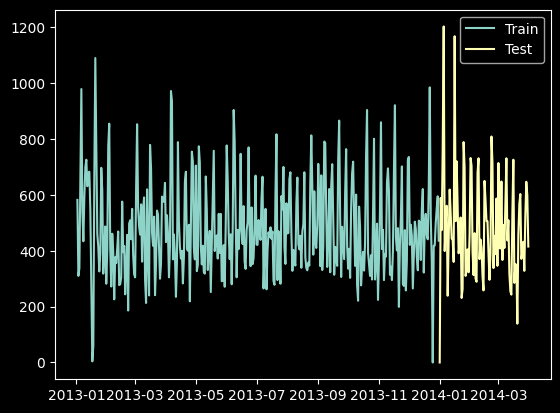

In [6]:
plt.plot(train.time_index, train.values(), label='Train')
plt.plot(test.time_index, test.values(), label='Test')
plt.legend()

In [7]:
# Train Arima model
arima_model = ARIMA(p=3, d=0, q=3)
arima_model.fit(train)

D:\data analytics\TimeSeries\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(p=3, d=0, q=3, seasonal_order=(0, 0, 0, 0), trend=None, random_state=None, add_encoders=None)

In [8]:
# Forecast
arima_forecast = arima_model.predict(len(test))

In [9]:
# Evaluate Arima model
arima_mape = mape(test, arima_forecast)
arima_rmse = rmse(test, arima_forecast)
arima_mae = mae(test, arima_forecast)
arima_r2 = r2_score(test, arima_forecast)

print(f"ARIMA Model - MAPE: {arima_mape}, RMSE: {arima_rmse}, MAE: {arima_mae}, R2: {arima_r2}")

ValueError: `actual_series` must be strictly positive to compute the MAPE.


ValueError: `actual_series` must be strictly positive to compute the MAPE.

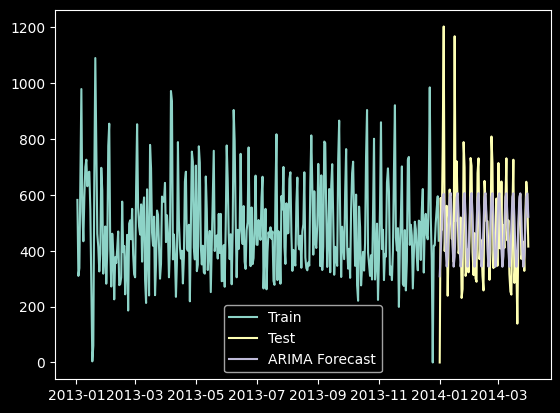

In [10]:
plt.plot(train.time_index, train.values(), label='Train')
plt.plot(test.time_index, test.values(), label='Test')
plt.plot(arima_forecast.time_index, arima_forecast.values(), label='ARIMA Forecast')
plt.legend()

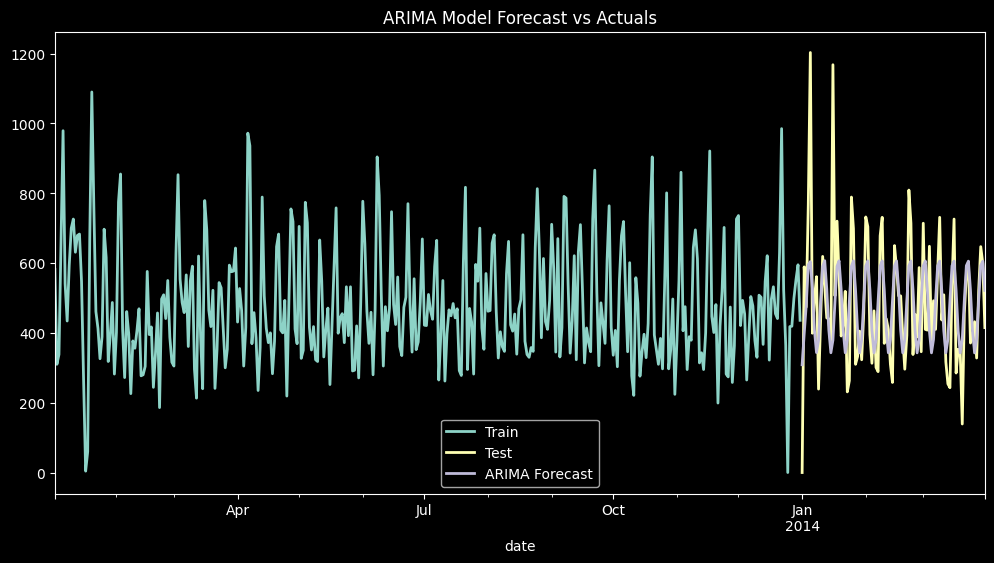

In [11]:
# Visualize Arima forecast against actuals

plt.figure(figsize=(12, 6))
train.plot(label='Train')
test.plot(label='Test')
arima_forecast.plot(label='ARIMA Forecast')
plt.title('ARIMA Model Forecast vs Actuals')
plt.legend()
plt.show()

## Exponential Smoothing Model

In [ ]:

# Train Exponential Smoothing model
es_model = ExponentialSmoothing()
es_model.fit(train)
# Forecast
es_forecast = es_model.predict(len(test))

In [ ]:

# Evaluate Exponential Smoothing model
es_mape = mape(test, es_forecast)
es_rmse = rmse(test, es_forecast)
es_mae = mae(test, es_forecast)
es_r2 = r2_score(test, es_forecast)
print(f"Exponential Smoothing Model - MAPE: {es_mape}, RMSE: {es_rmse}, MAE: {es_mae}, R2: {es_r2}")

In [ ]:

# Visualize Exponential Smoothing forecast against actuals
plt.figure(figsize=(12, 6))
train.plot(label='Train')
test.plot(label='Test')
es_forecast.plot(label='Exponential Smoothing Forecast')
plt.title('Exponential Smoothing Model Forecast vs Actuals')
plt.legend()
plt.show()